In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import json
import joblib


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)


In [3]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
df.head()


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
0,2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
1,2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2,2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81
3,2015-01-01 02:00:00,8799.0,-0.4,95.0,-1.2,92.66,766.64
4,2015-01-01 03:00:00,8567.0,-0.6,95.0,-1.3,92.66,733.13


In [4]:
target = "load_actual"

X = df[feature_names]
y = df[target]

In [5]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))


In [6]:
train_size = int(len(df) * 0.8)

X_train = X_scaled[:train_size]
X_test  = X_scaled[train_size:]

y_train = y_scaled[:train_size]
y_test  = y_scaled[train_size:]


In [7]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=11,
    verbose=1
)


Epoch 1/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.0270 - val_loss: 0.0242
Epoch 2/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.0246 - val_loss: 0.0239
Epoch 3/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0244 - val_loss: 0.0244
Epoch 4/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0242 - val_loss: 0.0234
Epoch 5/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0240 - val_loss: 0.0237
Epoch 6/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0240 - val_loss: 0.0235
Epoch 7/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.0238 - val_loss: 0.0231
Epoch 8/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.0238 - val_loss: 0.0234
Epoch 9/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 6s 978us/step - loss: 0.0238 - val_loss: 0.0230
Epoch 10/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 6s 962us/step - loss: 0.0236 - val_loss: 0.0230
Epoch 11/50
5738/5738 ━━━━━━━━━━━━━━━━━━━━ 6s 980us/step - loss: 0.0236 - val_loss: 0.0230
Epoch 12/50
5738/5738 ━━

In [9]:
pred_scaled = model.predict(X_test)
pred = scaler_y.inverse_transform(pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)


548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step


In [10]:
mae_bp = mean_absolute_error(y_test_actual, pred)
rmse_bp = mean_squared_error(y_test_actual, pred) ** 0.5
mape_bp = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100

print("BP-Neural Network Results:")
print("MAE:", mae_bp)
print("RMSE:", rmse_bp)
print("MAPE:", mape_bp)


BP-Neural Network Results:
MAE: 890.0442788397077
RMSE: 1087.4932934683818
MAPE: 9.455627530660536


In [11]:
model.save("../saved_models/bpnn_model.h5")
joblib.dump(scaler_X, "../saved_models/bpnn_scaler_X.pkl")
joblib.dump(scaler_y, "../saved_models/bpnn_scaler_y.pkl")


['../saved_models/bpnn_scaler_y.pkl']

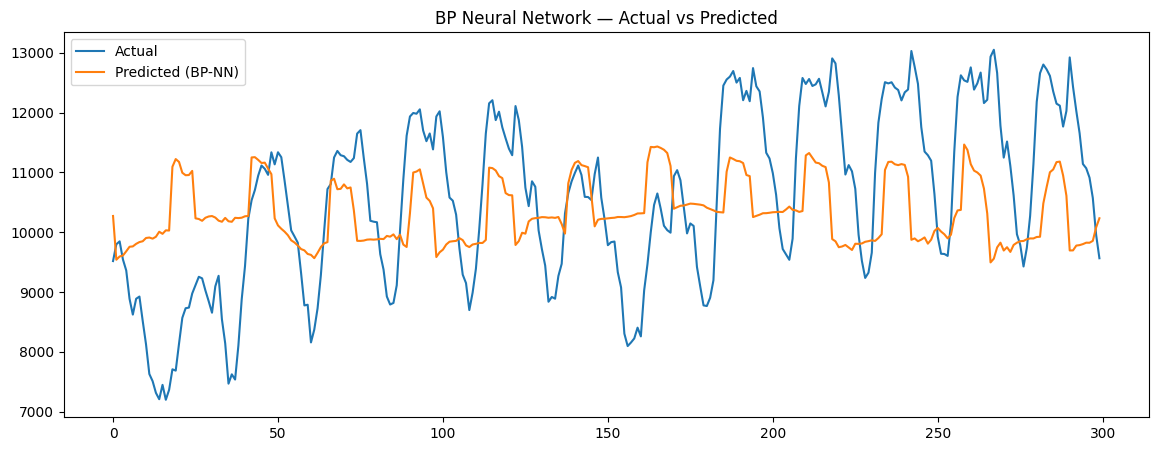

In [12]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(pred[:300], label="Predicted (BP-NN)")
plt.legend()
plt.title("BP Neural Network — Actual vs Predicted")
plt.show()
